In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')

from matplotlib import ticker
%matplotlib inline
import os

In [2]:
def contour_plot_MM(data, cut, levels_MM, snr_list=None):
    fres = data[0]
    dt = -data[1]
    MM = data[2]

    x_fres = cut[0]
    dt_cut = -cut[1]

    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    #ax.tick_params(axis="both", which="both", color="white", labelcolor="black")

    ax.set_yscale('log')
    
    # Filled contour
    plt.contourf(fres, dt, MM, levels=levels_MM, cmap = 'plasma',locator=ticker.LogLocator())

    #cut
    plt.plot(x_fres, dt_cut, color="red", label="Match approximation cut")

    # Add extra contour lines at specified fixed mismatch values
    if snr_list is not None:
        fixed_mismatch_values = [1./(2.*snr**2) for snr in snr_list]
        for mismatch_value, snr_value in zip(fixed_mismatch_values, snr_list):
            fixed_CS = ax.contour(fres, dt, MM, levels=[mismatch_value], colors='k')
            ax.clabel(fixed_CS, fixed_CS.levels, inline=True, fontsize=10, fmt={mismatch_value: f'SNR={snr_value:.0f}'}, inline_spacing=5)  # Adjust spacing for red labels

    # Labels
    plt.xlabel('Resonant Frequency [Hz]', size=10)
    plt.ylabel('Time shift [s]', size=10)
    #plt.title(rf'Detectable mode excitation. $M_1={m1}, M_2={m2}$', size=10)
    plt.title('(a)', size=10)
    
    plt.ylim(dt[0][0],dt[-1][0])
    plt.xlim(fres[0][0],400)

    # Colorbar
    cbar = plt.colorbar()
    cbar.set_label("Mismatch", size=10)

In [3]:
def contour_plot_dE(data, levels_dE):
    fres = data[0]
    dt = -data[1]
    dE = data[3]

    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    #ax.tick_params(axis="both", which="both", color="white", labelcolor="black")
    #CS = ax.contour(fres, dt, dE, levels=levels_dE, colors='w')
    #ax.clabel(CS, CS.levels, inline=True, fontsize=12)
    ax.set_yscale('log')
    #ax.set_ylim(4e-4,1e-1)

    plt.contourf(fres, dt, dE, levels=levels_dE, cmap = 'viridis',locator=ticker.LogLocator())
    
    plt.xlabel('Resonant Frequency [Hz]', size=10)
    plt.ylabel('Time shift [s]',size=10)
    #plt.title(rf'Energy transferred to the modes. $M_1={m1}, M_2={m2}$', size=10)
    plt.title('(b)', size=10)
    
    plt.xlim(fres[0][0],400)

    cbar=plt.colorbar()
    cbar.set_label("Energy [erg]", size=10)

In [4]:
def contour_plot_dF(data, levels_dF):
    fres = data[0]
    dt = -data[1]
    dF = -data[4]

    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    #ax.tick_params(axis="both", which="both", color="white", labelcolor="black")
    #CS = ax.contour(fres, dt, dF, levels=levels_dF, colors='w')
    #ax.clabel(CS, CS.levels, inline=True, fontsize=12)
    ax.set_yscale('log')
    #ax.set_ylim(4e-4,1e-1)

    plt.contourf(fres, dt, dF, levels=levels_dF, cmap = 'cividis',locator=ticker.LogLocator())
    
    plt.xlabel('Resonant Frequency [Hz]', size=10)
    plt.ylabel('Time shift [s]',size=10)
    #plt.title(rf'Resonant to orbital flux ratio. $M_1={m1}, M_2={m2}$', size=10)
    plt.title('(c)', size=10)

    plt.xlim(fres[0][0],400)

    cbar=plt.colorbar()
    cbar.set_label("Flux ratio", size=10)

In [5]:
data_path = '../data/mismatch_plots_data'
os.makedirs(data_path, exist_ok=True) 

figures_path = '../figures/mismatch_plots'
os.makedirs(figures_path, exist_ok=True)

In [6]:
m2 = 1.4
m1 = 1. * 1.4

# [X, Delta_t, M, F]
data = np.load(os.path.join(data_path, f'MM_dE_{m1}.npz'))['data']

cut = np.load(os.path.join(data_path, f'cut_{m1}.npz'))['data']

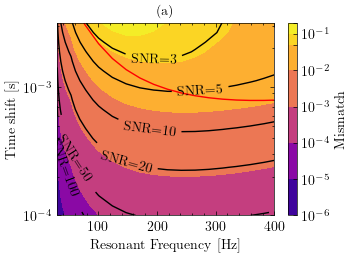

In [7]:
snr_list = [100., 50.,20., 10.,5.,3.]
contour_plot_MM(data,cut,[1e-6,1e-5,1e-4,1e-3,1e-2,5e-2,0.1,0.2], snr_list) 
#plt.ylim(4e-4,2e-2)
plt.savefig(os.path.join(figures_path, f"MM_{m1}.png"), dpi=300)

#plt.xlim(150,500)

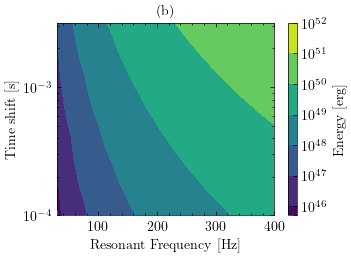

In [8]:
contour_plot_dE(data, [5e45,1e46,1e47,1e48,1e49,1e50,1e51,1e52]) 
#plt.ylim(4e-4,2e-2)
plt.savefig(os.path.join(figures_path, f"dE_{m1}.png"), dpi=300)

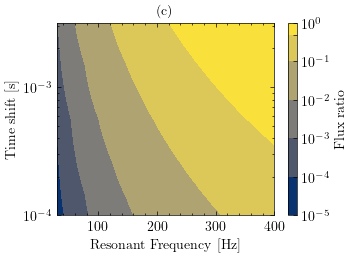

In [9]:
contour_plot_dF(data, [0.00001,0.0001,0.001,0.01,0.1,0.5,1])
#plt.ylim(4e-4,2e-2)
plt.savefig(os.path.join(figures_path, f"dF_{m1}.png"), dpi=300)

In [10]:
m2 = 1.4
m1 = 2.8

# [X, Delta_t, M, F]
data = np.load(os.path.join(data_path, f'MM_dE_{m1}.npz'))['data']

cut = np.load(os.path.join(data_path, f'cut_{m1}.npz'))['data']

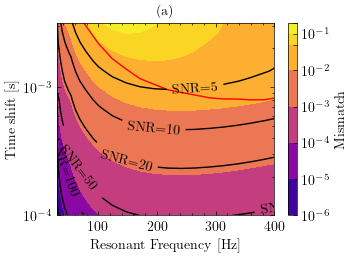

In [11]:
snr_list = [2000.,1000.,500.,200., 100., 50.,20., 10.,5.]
contour_plot_MM(data,cut,[1e-6,1e-5,1e-4,1e-3,1e-2,5e-2,0.1,0.2], snr_list) 
#plt.ylim(4e-4,2e-2)
plt.savefig(os.path.join(figures_path, f"MM_{m1}.png"))

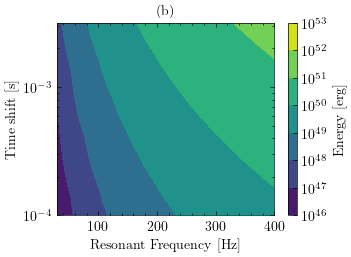

In [12]:
contour_plot_dE(data, [1e46,1e47,1e48,1e49,1e50,1e51,1e52,1e53]) 
#plt.ylim(4e-4,2e-2)
plt.savefig(os.path.join(figures_path, f"dE_{m1}.png"))

/tmp/ipykernel_18749/451382572.py:13: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(fres, dt, dF, levels=levels_dF, cmap = 'cividis',locator=ticker.LogLocator())


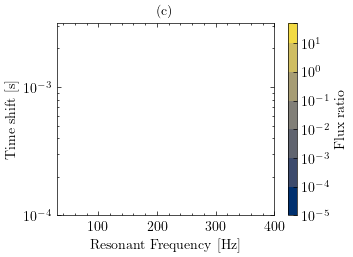

In [13]:
contour_plot_dF(data, [0.00001,0.0001,0.001,0.01,0.1,1,10,50])
#plt.ylim(4e-4,2e-2)
plt.savefig(os.path.join(figures_path, f"dF_{m1}.png"))

In [14]:
m2 = 1.4
m1 = 4.2

# [X, Delta_t, M, F]
data = np.load(os.path.join(data_path, f'MM_dE_{m1}.npz'))['data']

cut = np.load(os.path.join(data_path, f'cut_{m1}.npz'))['data']

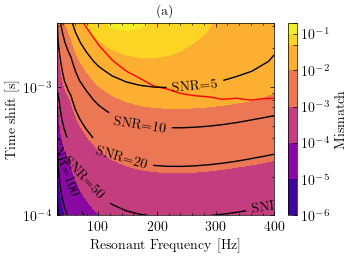

In [15]:
snr_list = [2000.,1000.,500.,200., 100., 50.,20., 10.,5.]
contour_plot_MM(data,cut,[1e-6,1e-5,1e-4,1e-3,1e-2,5e-2,0.1,0.2], snr_list) 
#plt.ylim(4e-4,2e-2)
plt.savefig(os.path.join(figures_path, f"MM_{m1}.png"))

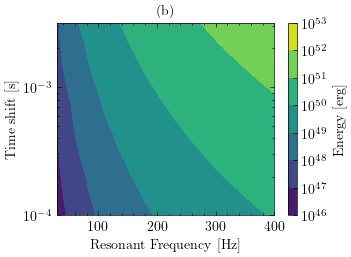

In [16]:
contour_plot_dE(data, [1e46,1e47,1e48,1e49,1e50,1e51,1e52,1e53]) 
#plt.ylim(4e-4,2e-2)
plt.savefig(os.path.join(figures_path, f"dE_{m1}.png"))

/tmp/ipykernel_18749/451382572.py:13: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(fres, dt, dF, levels=levels_dF, cmap = 'cividis',locator=ticker.LogLocator())


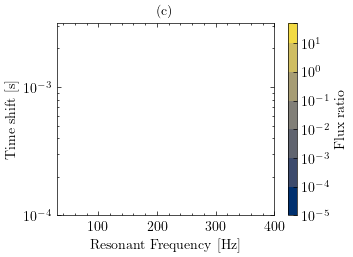

In [17]:
contour_plot_dF(data, [0.00001,0.0001,0.001,0.01,0.1,1,10,50])
#plt.ylim(4e-4,2e-2)
plt.savefig(os.path.join(figures_path, f"dF_{m1}.png"))